In [35]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation

In [36]:
#loading data
import pandas as pd

file_id = "1SJcoCmSKSv2lRfdyKpiypk1cUBaLBD6C"

url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)

df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [37]:
df.shape
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


,0
Review Id,0
Review,6
Ratings,0
Review Date,0


In [38]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,review_id,review,ratings,review_date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [39]:
# Ensure data types are appropriate (e.g., ratings as numeric).

df['review_date'] = pd.to_datetime(df['review_date'],errors='coerce')
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

# Handle missing reviews

df['review'] = df['review'].fillna('') # replaces missing values with an empty string.

In [40]:
df.isnull().sum()

,0
review_id,0
review,0
ratings,0
review_date,0


In [41]:
# check duplicates:
df.duplicated().sum()

np.int64(2511)

In [42]:
df[df.duplicated()]

,review_id,review,ratings,review_date
79518,cb1c2e68-8d30-4361-a6d6-2ee0cedc6522,The best app ever,5,2024-05-17 12:14:35
79519,54c7f809-bc21-4a4e-8370-5c2c5f4feedb,chup saale,1,2024-05-17 12:14:05
79520,d24a6482-0ec4-4e09-b576-03ea87f8a702,very useful,5,2024-05-17 12:13:47
79521,d1072c90-f7a6-4556-b070-419c787d4b9c,Fantastic,5,2024-05-17 12:13:22
79522,a615f86c-49a5-45d5-a2e1-1816b550b3ca,أفضل موقع لي المعلومات 👍,5,2024-05-17 12:11:50
...,...,...,...,...
193461,b5712561-2466-4bb8-9411-1c17f33e7c98,good for students 🤝,5,2024-05-12 01:44:12
194527,50aa02af-85b3-48ae-a7e1-d703477506c3,Exceptional app,5,2024-05-12 05:05:18
195617,7a58afce-290e-4c2b-8c42-636977af77b8,I am get all the question answers free and real,5,2024-05-12 03:57:21
195737,be58db7e-8807-4f6f-99e4-ac76a5361108,Is terrible just terrible,1,2024-05-12 08:41:47


In [43]:
df['review_id'].duplicated().sum()

np.int64(3573)

In [44]:
# investigate before deleting anything
df[df['review_id'].duplicated(keep=False)].sort_values('review_id').head(20)

,review_id,review,ratings,review_date
78968,0009b10b-59f3-4c66-a68d-d330ad280a55,သဘောတွေ့ပါတယ်ခက်ဗျာ,5,2024-05-17 10:26:45
79634,0009b10b-59f3-4c66-a68d-d330ad280a55,သဘောတွေ့ပါတယ်ခက်ဗျာ,5,2024-05-17 10:26:45
80290,0009b10b-59f3-4c66-a68d-d330ad280a55,သဘောတွေ့ပါတယ်ခက်ဗျာ,5,2024-05-17 10:26:45
79372,000ca1a5-ed93-4cf2-875e-6e8bb4941bf6,good,5,2024-05-17 03:54:56
80694,000ca1a5-ed93-4cf2-875e-6e8bb4941bf6,good,5,2024-05-17 03:54:56
80038,000ca1a5-ed93-4cf2-875e-6e8bb4941bf6,good,5,2024-05-17 03:54:56
2254,003818b9-6f10-4d69-bd8c-2fe4e6393961,very great app,5,2024-08-21 15:31:36
11354,003818b9-6f10-4d69-bd8c-2fe4e6393961,very great app,5,2024-08-11 16:08:15
16131,00527c7e-9ea8-4477-a611-b391c00defc1,I can't sign in using Microsoft account. It ju...,1,2024-08-06 03:06:58
65871,00527c7e-9ea8-4477-a611-b391c00defc1,I can't assign in using Microsoft account. It ...,2,2024-05-29 17:56:50


In [45]:
df['review_id'].nunique()


193154

In [17]:
# show only those repeated Review IDs that actually look like
df[df['review_id'].duplicated(keep=False)].sort_values('review_id').head(20)

,review_id,review,ratings,review_date
78968,0009b10b-59f3-4c66-a68d-d330ad280a55,သဘောတွေ့ပါတယ်ခက်ဗျာ,5,2024-05-17 10:26:45
79634,0009b10b-59f3-4c66-a68d-d330ad280a55,သဘောတွေ့ပါတယ်ခက်ဗျာ,5,2024-05-17 10:26:45
80290,0009b10b-59f3-4c66-a68d-d330ad280a55,သဘောတွေ့ပါတယ်ခက်ဗျာ,5,2024-05-17 10:26:45
79372,000ca1a5-ed93-4cf2-875e-6e8bb4941bf6,good,5,2024-05-17 03:54:56
80694,000ca1a5-ed93-4cf2-875e-6e8bb4941bf6,good,5,2024-05-17 03:54:56
80038,000ca1a5-ed93-4cf2-875e-6e8bb4941bf6,good,5,2024-05-17 03:54:56
2254,003818b9-6f10-4d69-bd8c-2fe4e6393961,very great app,5,2024-08-21 15:31:36
11354,003818b9-6f10-4d69-bd8c-2fe4e6393961,very great app,5,2024-08-11 16:08:15
16131,00527c7e-9ea8-4477-a611-b391c00defc1,I can't sign in using Microsoft account. It ju...,1,2024-08-06 03:06:58
65871,00527c7e-9ea8-4477-a611-b391c00defc1,I can't assign in using Microsoft account. It ...,2,2024-05-29 17:56:50


In [46]:
# remove only exact duplicate rows.
df = df.drop_duplicates()

In [47]:
print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Shape after removing duplicates: (194216, 4)
Remaining duplicate rows: 0


# Analysis


# Rating distribution analysis

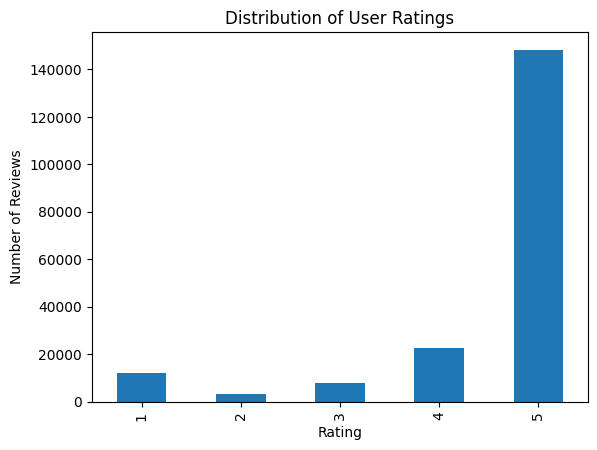

In [48]:


df['ratings'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

In [49]:
# Review Length
df = df.copy()

df['review_length'] = df['review'].str.len()
df[['review', 'review_length']].head()

,review,review_length
0,good,4
1,good,4
2,nice app,8
3,"nice, ig",8
4,"this is a great app, the bot is so accurate to...",368


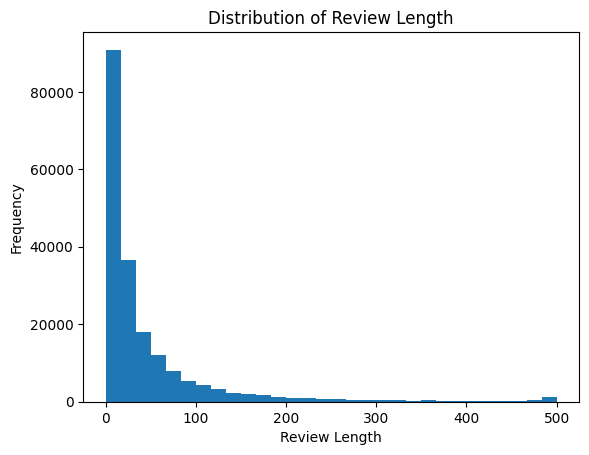

In [50]:
# Visualize distribution of review length
df['review_length'].plot(kind='hist', bins=30)
plt.title('Distribution of Review Length')
plt.xlabel('Review Length')
plt.show()

# Sentiment Analysis

In [51]:

from textblob import TextBlob

df['polarity'] = df['review'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df['subjectivity'] = df['review'].apply(
    lambda x: TextBlob(x).sentiment.subjectivity
)

In [52]:
df[['review', 'polarity', 'subjectivity']].head()

,review,polarity,subjectivity
0,good,0.7000,0.600000
1,good,0.7000,0.600000
2,nice app,0.6000,1.000000
3,"nice, ig",0.6000,1.000000
4,"this is a great app, the bot is so accurate to...",0.4125,0.542949


In [53]:
def sentiment_category(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['polarity'].apply(sentiment_category)


In [54]:
df[['review', 'polarity', 'subjectivity','sentiment']].head()

,review,polarity,subjectivity,sentiment
0,good,0.7000,0.600000,Positive
1,good,0.7000,0.600000,Positive
2,nice app,0.6000,1.000000,Positive
3,"nice, ig",0.6000,1.000000,Positive
4,"this is a great app, the bot is so accurate to...",0.4125,0.542949,Positive


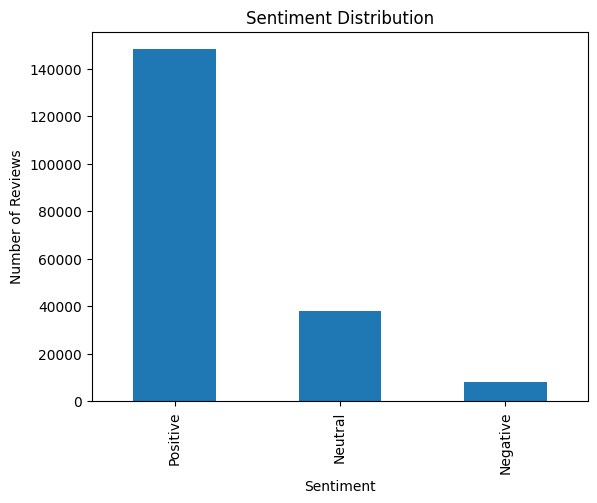

In [55]:
# Visualize Sentiment Distribution
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

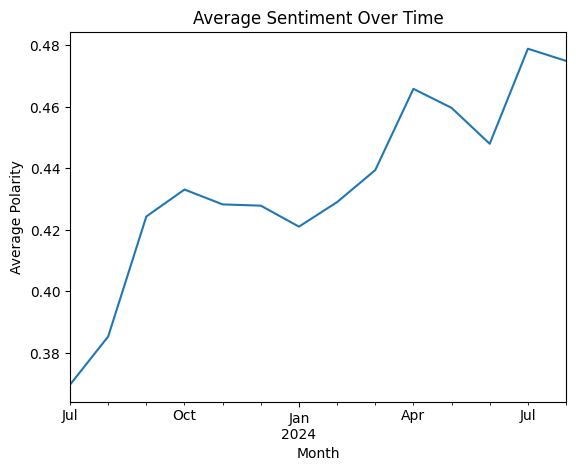

In [56]:
df['month'] = df['review_date'].dt.to_period('M')

monthly_sentiment = df.groupby('month')['polarity'].mean()

monthly_sentiment.plot(kind='line')

plt.title('Average Sentiment Over Time')
plt.xlabel('Month')
plt.ylabel('Average Polarity')
plt.show()

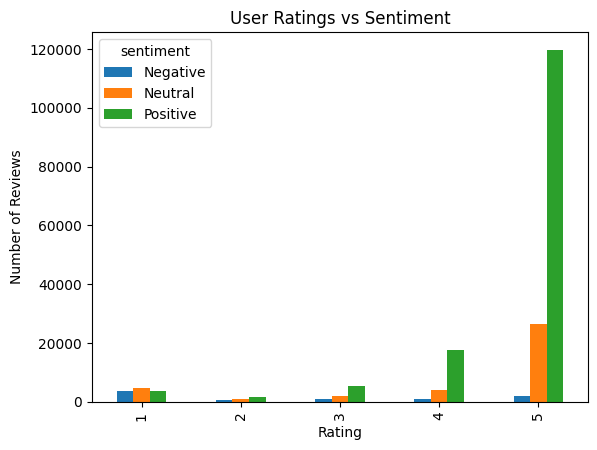

In [57]:
pd.crosstab(df['ratings'], df['sentiment'])
pd.crosstab(df['ratings'], df['sentiment']).plot(kind='bar')
plt.title('User Ratings vs Sentiment')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# Text Analysis

In [58]:
# Positive Keyword Analysis (frequently mentioned positive keywords)

positive_reviews = df[df['sentiment'] == 'Positive'] # select positive reviews
positive_text = ' '.join(positive_reviews['review']) # Combine the reviews

# extract frequently occurring words after removing stopwords

from collections import Counter
import re

words = re.findall(r'\b[a-zA-Z]{3,}\b', positive_text.lower()) # f                                                                                                              ind all English words containing at least 3 letters

stop_words = {
    'the', 'and', 'for', 'that', 'this', 'with',
    'you', 'was', 'are', 'have', 'but', 'not',
    'very', 'from', 'they', 'its', 'can', 'has'
}

filtered_words = [
    word for word in words
    if word not in stop_words
]

word_counts = Counter(filtered_words)

word_counts.most_common(20)

[('app', 44374),
 ('good', 38637),
 ('best', 18087),
 ('nice', 13610),
 ('great', 11788),
 ('helpful', 9607),
 ('amazing', 8558),
 ('love', 8524),
 ('chatgpt', 8345),
 ('useful', 7474),
 ('really', 7015),
 ('like', 6918),
 ('use', 6169),
 ('excellent', 6068),
 ('all', 5112),
 ('awesome', 5014),
 ('just', 4942),
 ('more', 4826),
 ('chat', 4791),
 ('gpt', 4003)]

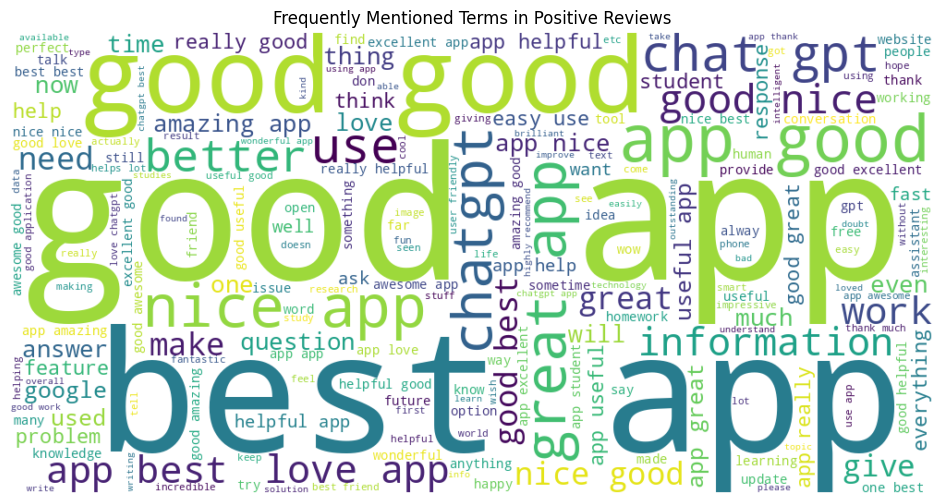

In [59]:
from wordcloud import WordCloud

cleaned_positive_text = ' '.join(filtered_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(cleaned_positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Frequently Mentioned Terms in Positive Reviews')
plt.show()

# Key Insights

1. Users frequently use positive words such as good, great, helpful, useful, amazing, and love.

2. Continue improving the features that users describe as helpful and useful, because these are strongly represented in positive feedback.

3. Monitor both ratings and review sentiment. Ratings tell us how satisfied users are, while review text can help explain why users feel that way.

4. Continuous monitoring of sentiment over time can help identify whether customer feedback is becoming more positive or negative and can also help evaluate the potential impact of future product improvements.